In [244]:
import os
import hopsworks
import pandas as pd
import joblib
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [245]:
# 1. Load your API key
load_dotenv()
api_key = os.getenv("HopsworkAPI_KEY")

project = hopsworks.login(api_key_value=api_key)

fs = project.get_feature_store()

fg = fs.get_feature_group("sialkot_aqi_features_v2", version=1)
xf = fg.read()

2026-06-04 23:58:16,689 INFO: Closing external client and cleaning up certificates.
2026-06-04 23:58:16,698 INFO: Connection closed.
2026-06-04 23:58:16,700 INFO: Initializing external client
2026-06-04 23:58:16,700 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-06-04 23:58:19,706 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/32895
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (10.08s) 


In [246]:
df = xf

In [247]:
df

,datetime,wind_speed_100m,precipitation,apparent_temperature,wind_gusts_10m,vapour_pressure_deficit,relative_humidity_2m,aqi,co,no2,o3,so2,pm2_5,pm10,nh3,date,hour,city
0,2026-06-02 18:00:00,19.5,0.0,30.1,17.3,1.25,66,5,1064.15,29.08,103.20,12.05,76.96,99.32,162.95,2026-06-02,18,Sialkot
1,2026-06-02 19:00:00,15.6,0.0,29.4,18.4,1.25,65,5,1184.16,31.06,80.85,9.77,83.33,106.42,144.22,2026-06-02,19,Sialkot
2,2026-06-02 20:00:00,13.7,0.0,29.2,14.8,1.06,69,5,1299.39,32.35,61.64,7.41,88.20,111.65,119.65,2026-06-02,20,Sialkot
3,2026-06-02 21:00:00,13.0,0.0,29.0,11.5,0.93,72,5,1407.06,33.61,46.80,5.72,91.75,115.04,102.16,2026-06-02,21,Sialkot
4,2026-06-02 22:00:00,14.5,0.0,28.6,13.0,0.91,72,5,1477.30,33.57,36.01,4.55,92.38,114.45,89.86,2026-06-02,22,Sialkot
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2732,2026-05-31 20:00:00,13.8,0.0,28.4,13.7,1.24,63,3,546.83,10.16,90.90,3.98,33.73,44.00,74.03,2026-05-31,20,Sialkot
2733,2026-05-31 21:00:00,12.1,0.0,28.2,9.0,1.05,68,3,512.80,8.73,89.43,3.74,33.55,42.93,76.33,2026-05-31,21,Sialkot
2734,2026-05-31 22:00:00,12.7,0.0,28.0,9.4,1.00,69,3,484.12,7.57,87.81,3.62,33.77,42.59,77.28,2026-05-31,22,Sialkot
2735,2026-05-31 23:00:00,10.6,0.0,27.9,8.6,0.85,73,3,467.00,6.77,87.20,3.60,34.63,43.12,77.39,2026-05-31,23,Sialkot


In [248]:
# Have access to future weather via Open-Meteo!
df['temp_lag1'] = df['apparent_temperature'].shift(1)
df['wind_rolling_6'] = df['wind_speed_100m'].rolling(6).mean()

In [249]:
df['day_of_week'] = df['datetime'].dt.dayofweek
df['month']       = df['datetime'].dt.month
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

In [250]:
import numpy as np

# Convert the 24-hour clock into a mathematical circle using Sine and Cosine
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

In [257]:
# You can now safely drop the raw 'hour' column
df = df.drop(columns=['hour'])

In [251]:
df = df.dropna().reset_index(drop=True)

In [258]:
print("🔪 Preparing data and splitting features...")
df = df.sort_values('datetime').reset_index(drop=True)

# We drop columns that leak the answer, or that math can't understand
columns_to_drop = ['city', 'date', 'datetime', 'aqi', 'pm2_5', 'pm10']

# TODO: Create your 'X' dataframe by dropping the columns above
X = df.drop(columns=columns_to_drop)

# TODO: Create your 'y' series using ONLY the 'pm2_5' column
y = df['pm2_5']

# TODO: Use train_test_split to hide 20% of the data. Set random_state=42 for reproducibility.
# CORRECT FOR TIME SERIES (Chronological Cut)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


🔪 Preparing data and splitting features...


In [259]:
X_train

,wind_speed_100m,precipitation,apparent_temperature,wind_gusts_10m,vapour_pressure_deficit,relative_humidity_2m,co,no2,o3,so2,nh3,temp_lag1,wind_rolling_6,day_of_week,month,is_weekend,hour_sin,hour_cos
0,0.6,0.0,9.3,2.5,0.00,100,2435.33,24.59,4.33,1.30,5.82,30.3,11.900000,6,2,1,0.000000,1.000000
1,8.6,0.0,9.4,10.8,0.04,97,2413.72,23.49,3.61,1.26,12.67,9.3,11.683333,6,2,1,0.258819,0.965926
2,3.3,0.0,8.4,9.0,0.00,100,2466.80,23.53,2.63,1.66,15.17,9.4,10.150000,6,2,1,0.500000,0.866025
3,5.2,0.0,9.4,10.1,0.04,97,2593.56,24.47,2.44,2.10,15.36,8.4,9.100000,6,2,1,0.707107,0.707107
4,7.4,0.0,12.4,10.8,0.12,92,2658.71,22.94,8.73,2.35,14.31,9.4,7.350000,6,2,1,0.866025,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2180,11.9,0.0,26.0,13.3,1.16,62,946.66,19.63,79.36,6.57,80.13,26.5,13.050000,4,5,0,-0.866025,0.500000
2181,9.4,0.0,25.5,10.4,0.99,66,902.98,17.09,74.64,5.32,82.78,26.0,12.300000,4,5,0,-0.707107,0.707107
2182,10.5,0.0,24.9,11.2,0.94,67,850.10,14.72,71.60,4.42,83.96,25.5,11.700000,4,5,0,-0.500000,0.866025
2183,10.2,0.0,24.3,11.9,0.85,70,795.59,12.55,71.27,3.88,84.73,24.9,11.333333,4,5,0,-0.258819,0.965926


In [260]:
y_train

0       346.10
1       353.64
2       365.58
3       379.25
4       382.61
         ...  
2180     63.98
2181     63.73
2182     62.93
2183     61.93
2184     60.89
Name: pm2_5, Length: 2185, dtype: float64

In [261]:
X.head(5)

,wind_speed_100m,precipitation,apparent_temperature,wind_gusts_10m,vapour_pressure_deficit,relative_humidity_2m,co,no2,o3,so2,nh3,temp_lag1,wind_rolling_6,day_of_week,month,is_weekend,hour_sin,hour_cos
0,0.6,0.0,9.3,2.5,0.00,100,2435.33,24.59,4.33,1.30,5.82,30.3,11.900000,6,2,1,0.000000,1.000000
1,8.6,0.0,9.4,10.8,0.04,97,2413.72,23.49,3.61,1.26,12.67,9.3,11.683333,6,2,1,0.258819,0.965926
2,3.3,0.0,8.4,9.0,0.00,100,2466.80,23.53,2.63,1.66,15.17,9.4,10.150000,6,2,1,0.500000,0.866025
3,5.2,0.0,9.4,10.1,0.04,97,2593.56,24.47,2.44,2.10,15.36,8.4,9.100000,6,2,1,0.707107,0.707107
4,7.4,0.0,12.4,10.8,0.12,92,2658.71,22.94,8.73,2.35,14.31,9.4,7.350000,6,2,1,0.866025,0.500000


In [262]:
# Initialize the competitors
models = {
    "Ridge_Regression": Ridge(),
    "Random_Forest": RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42),
    "XGBoost": XGBRegressor(learning_rate=0.1, max_depth=6, n_estimators=200, random_state=42)
}

In [263]:
results = {}

# Train and evaluate each model in a loop
for name, model in models.items():
    # TODO: Train the model using the .fit() method on your training data
    model.fit(X_train, y_train)
    
    # TODO: Ask the model to predict PM2.5 for the hidden X_test data
    predictions = model.predict(X_test)
    
    # TODO: Calculate the three required metrics by comparing 'predictions' to 'y_test'
    rmse = root_mean_squared_error(y_test, predictions) 
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2, "model_object": model}
    print(f"✅ {name} trained. R2 Score: {r2:.3f}")

✅ Ridge_Regression trained. R2 Score: 0.438
✅ Random_Forest trained. R2 Score: 0.529
✅ XGBoost trained. R2 Score: 0.604


In [236]:
results['Ridge_Regression']

{'RMSE': 16.57959734932186,
 'MAE': 13.12126275818328,
 'R2': 0.438288722334911,
 'model_object': Ridge()}

In [237]:
results['Random_Forest']

{'RMSE': 15.181562831496313,
 'MAE': 11.286106771359943,
 'R2': 0.5290246821688516,
 'model_object': RandomForestRegressor(max_depth=10, min_samples_split=5, n_estimators=200,
                       random_state=42)}

In [238]:
results['XGBoost']

{'RMSE': 13.928983569612805,
 'MAE': 10.318995817278596,
 'R2': 0.6035357452143221,
 'model_object': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)}

In [239]:
best_model_name = max(results, key=lambda k: results[k]['R2'])
best_metrics = results[best_model_name]
champion_model = best_metrics['model_object']

print(f"\n🏆 WINNER: {best_model_name} with an R2 of {best_metrics['R2']:.3f}")


🏆 WINNER: XGBoost with an R2 of 0.604


In [240]:
import shap
import matplotlib.pyplot as plt

In [241]:
# 1. Initialize JS visualization for the notebook
shap.initjs()

# 2. Create the SHAP Explainer specific to tree-based models (Random Forest)
explainer = shap.TreeExplainer(model)

# 3. Calculate SHAP values for your testing data
# (This might take 10-20 seconds depending on your machine)
shap_values = explainer.shap_values(X_test)

print("✅ SHAP values calculated successfully!")

✅ SHAP values calculated successfully!


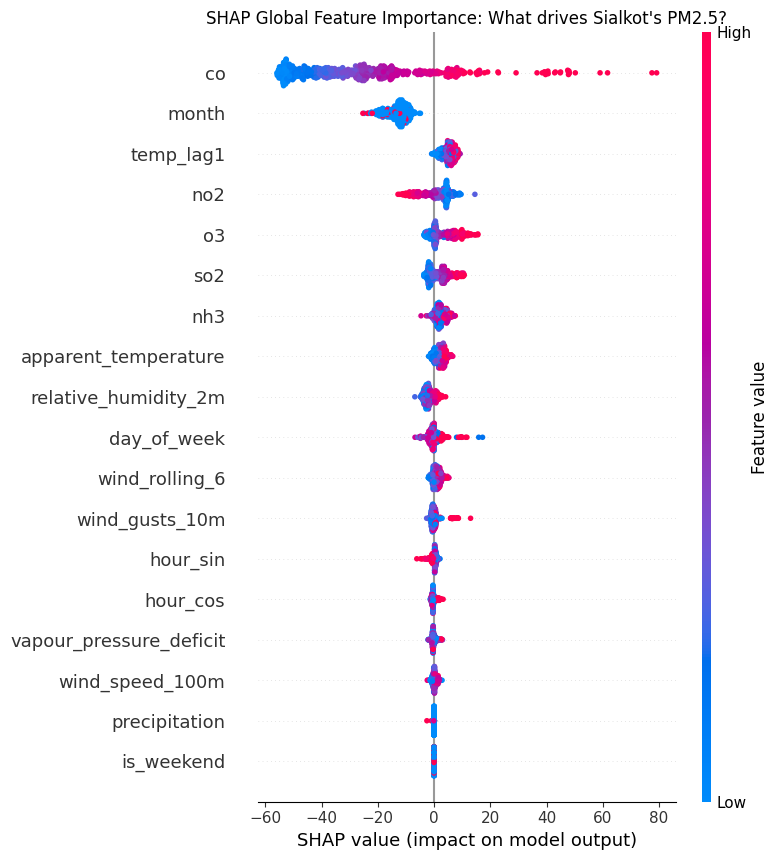

In [242]:
# Plot the global summary (Beeswarm plot)
plt.title("SHAP Global Feature Importance: What drives Sialkot's PM2.5?")
shap.summary_plot(shap_values, X_test)

In [243]:
# Explain the very first prediction in your test set (Hour 0)
# This creates an interactive HTML plot right in your notebook!
shap.force_plot(
    explainer.expected_value[0] if isinstance(explainer.expected_value, list) else explainer.expected_value, 
    shap_values[0], 
    X_test.iloc[0, :]
)